In [1]:
import os
import json
import pickle
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    roc_auc_score, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier


STEP 1 — LOAD & INSPECT
Shape          : (284807, 31)
Missing values : 0
Duplicates     : 1081

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud ratio    : 0.0017  (0.17%)

After dedup shape: (283726, 31)

STEP 2 — EDA


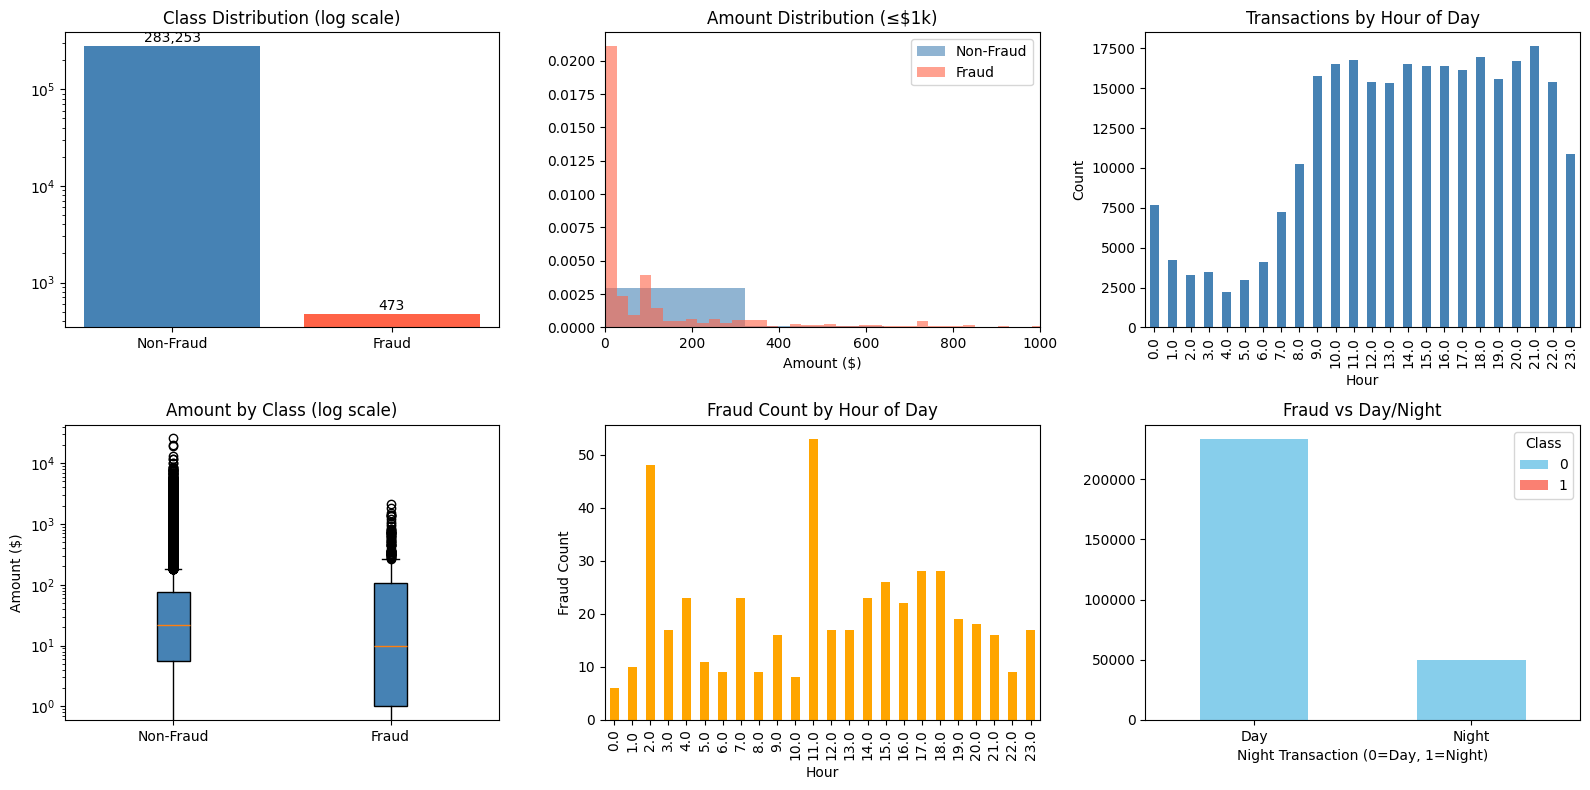

EDA plots saved → eda_plots.png


In [2]:
print("=" * 60)
print("STEP 1 — LOAD & INSPECT")
print("=" * 60)

df = pd.read_csv("creditcard.csv")

print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print(f"\nTarget distribution:\n{df['Class'].value_counts()}")
print(f"Fraud ratio    : {df['Class'].mean():.4f}  ({df['Class'].mean()*100:.2f}%)")

# Drop duplicates
df.drop_duplicates(inplace=True)
print(f"\nAfter dedup shape: {df.shape}")

target_col = "Class"

# %% Cell 2
print("\n" + "=" * 60)
print("STEP 2 — EDA")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Class balance
ax = axes[0, 0]
counts = df[target_col].value_counts()
ax.bar(["Non-Fraud", "Fraud"], counts.values, color=["steelblue", "tomato"])
ax.set_title("Class Distribution (log scale)")
ax.set_yscale("log")
for i, v in enumerate(counts.values):
    ax.text(i, v * 1.1, f"{v:,}", ha="center", fontsize=10)

# %% Cell 3
ax = axes[0, 1]
ax.hist(df[df["Class"] == 0]["Amount"], bins=80, alpha=0.6, color="steelblue",
        label="Non-Fraud", density=True)
ax.hist(df[df["Class"] == 1]["Amount"], bins=80, alpha=0.6, color="tomato",
        label="Fraud", density=True)
ax.set_xlim(0, 1000)
ax.set_title("Amount Distribution (≤$1k)")
ax.set_xlabel("Amount ($)")
ax.legend()

# %% Cell 4
# Time — hourly transaction volume
df["Hour"] = (df["Time"] // 3600) % 24
ax = axes[0, 2]
df.groupby("Hour").size().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Transactions by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Count")

# %% Cell 5
# Amount boxplot by class (log scale)
ax = axes[1, 0]
ax.boxplot(
    [df[df["Class"] == 0]["Amount"], df[df["Class"] == 1]["Amount"]],
    labels=["Non-Fraud", "Fraud"],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue"),
)
ax.set_yscale("log")
ax.set_title("Amount by Class (log scale)")
ax.set_ylabel("Amount ($)")

# %% Cell 6
ax = axes[1, 1]
df.groupby("Hour")["Class"].sum().plot(kind="bar", ax=ax, color="orange")
ax.set_title("Fraud Count by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Fraud Count")

# %% Cell 7
df["is_night"] = df["Hour"].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
night_fraud = df.groupby(["is_night", "Class"]).size().unstack(fill_value=0)
night_fraud.plot(kind="bar", stacked=True, ax=axes[1, 2],
                 color=["skyblue", "salmon"])
axes[1, 2].set_title("Fraud vs Day/Night")
axes[1, 2].set_xlabel("Night Transaction (0=Day, 1=Night)")
axes[1, 2].set_xticklabels(["Day", "Night"], rotation=0)

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=130, bbox_inches="tight")
plt.show()
print("EDA plots saved → eda_plots.png")


In [3]:
df_fe = df.copy()

# --- Amount features ---
df_fe["log_amount"]      = np.log1p(df_fe["Amount"])
df_fe["amount_log_sq"]   = df_fe["log_amount"] ** 2
df_fe["is_round_amount"] = (df_fe["Amount"] % 1 == 0).astype(int)
df_fe["is_small_amount"] = (df_fe["Amount"] < 1).astype(int)

# --- Time features — KEPT for Streamlit app ---
# Raw Time kept as-is (seconds since first transaction)
# Cyclic hour encoding so model understands 23 and 0 are adjacent
df_fe["hour_of_day"] = (df_fe["Time"] // 3600) % 24
df_fe["hour_sin"]    = np.sin(2 * np.pi * df_fe["hour_of_day"] / 24)
df_fe["hour_cos"]    = np.cos(2 * np.pi * df_fe["hour_of_day"] / 24)
df_fe["is_night"]    = df_fe["hour_of_day"].isin([0, 1, 2, 3, 4, 5, 22, 23]).astype(int)
# NOTE: Time (raw seconds) is kept — scaler handles the scale difference
# Do NOT drop Time — it's needed for the Streamlit app to accept live input

# --- V-column aggregate features ---
v_cols = [c for c in df_fe.columns if c.startswith("V")]
df_fe["v_sum_sq"]  = (df_fe[v_cols] ** 2).sum(axis=1)
df_fe["v_max_abs"] = df_fe[v_cols].abs().max(axis=1)

print("New features added:")
new_feats = ["log_amount", "amount_log_sq", "is_round_amount", "is_small_amount",
             "hour_of_day", "hour_sin", "hour_cos", "is_night", "v_sum_sq", "v_max_abs"]
for f in new_feats:
    print(f"  + {f}")

X = df_fe.drop(columns=[target_col])
y = df_fe[target_col].values



New features added:
  + log_amount
  + amount_log_sq
  + is_round_amount
  + is_small_amount
  + hour_of_day
  + hour_sin
  + hour_cos
  + is_night
  + v_sum_sq
  + v_max_abs


In [4]:
print("\n" + "=" * 60)
print("STEP 4 — TRAIN/TEST SPLIT")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}  fraud={y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test : {X_test.shape}   fraud={y_test.sum()} ({y_test.mean()*100:.2f}%)")

# %% Cell 10
print("\n" + "=" * 60)
print("STEP 5 — LEAKAGE-SAFE STATS FEATURES + SCALING")
print("=" * 60)

train_mean = X_train["Amount"].mean()
train_p99  = X_train["Amount"].quantile(0.99)

# Apply same train stats to both splits
for split in [X_train, X_test]:
    split["amount_to_mean"] = split["Amount"] / (train_mean + 1e-9)
    split["is_high_amount"] = (split["Amount"] > train_p99).astype(int)

print(f"train_mean = {train_mean:.4f}")
print(f"train_p99  = {train_p99:.4f}")



STEP 4 — TRAIN/TEST SPLIT
Train: (226980, 41)  fraud=378 (0.17%)
Test : (56746, 41)   fraud=95 (0.17%)

STEP 5 — LEAKAGE-SAFE STATS FEATURES + SCALING
train_mean = 88.3871
train_p99  = 1016.1597


In [5]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler = RobustScaler()
scaler.fit(X_train[numeric_features])

X_train_proc = X_train.copy()
X_test_proc  = X_test.copy()
X_train_proc[numeric_features] = scaler.transform(X_train[numeric_features])
X_test_proc[numeric_features]  = scaler.transform(X_test[numeric_features])

# Keep Time column in — scaler already normalized it
# Streamlit app will need it for live prediction

print(f"\nFinal feature count : {X_train_proc.shape[1]}")
print(f"Feature list (first 10): {list(X_train_proc.columns[:10])}")
FEATURE_ORDER = list(X_train_proc.columns)  # saved for Streamlit



Final feature count : 43
Feature list (first 10): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']


In [6]:
print("\n" + "=" * 60)
print("STEP 6 — CLASS IMBALANCE STRATEGY")
print("=" * 60)

neg   = int((y_train == 0).sum())
pos   = int((y_train == 1).sum())
SPW   = neg / pos   # scale_pos_weight for XGBoost
RATIO = neg / pos   # same value, explicit name

print(f"Legit (neg) : {neg:,}")
print(f"Fraud (pos) : {pos:,}")
print(f"scale_pos_weight = {SPW:.1f}  (tells XGB: each fraud = {SPW:.0f} legit samples)")
print("→ No SMOTE needed — scale_pos_weight handles imbalance with zero overhead")

# %% Cell 13



STEP 6 — CLASS IMBALANCE STRATEGY
Legit (neg) : 226,602
Fraud (pos) : 378
scale_pos_weight = 599.5  (tells XGB: each fraud = 599 legit samples)
→ No SMOTE needed — scale_pos_weight handles imbalance with zero overhead


In [8]:
ax = axes[1, 1]
df.groupby("Hour")["Class"].sum().plot(kind="bar", ax=ax, color="orange")
ax.set_title("Fraud Count by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Fraud Count")



Text(445.4493987757865, 0.5, 'Fraud Count')

In [7]:
print("=" * 60)
print("STEP 7 — OPTUNA HYPERPARAMETER TUNING")
print("=" * 60)
print("Objective  : maximize F1-score (balances precision & recall)")
print("Safety net : Precision must be >= 0.30 (else trial is rejected)")
print("CV         : StratifiedKFold(3)  — preserves fraud ratio per fold")
print("Metric     : average_precision (PR-AUC) → honest on imbalanced data")
print()


STEP 7 — OPTUNA HYPERPARAMETER TUNING
Objective  : maximize F1-score (balances precision & recall)
Safety net : Precision must be >= 0.30 (else trial is rejected)
CV         : StratifiedKFold(3)  — preserves fraud ratio per fold
Metric     : average_precision (PR-AUC) → honest on imbalanced data



In [8]:
import time
from sklearn.model_selection import cross_validate

PRECISION_FLOOR = 0.30   # below this, fraud team gets overwhelmed
N_TRIALS        = 30     # increase to 50-100 for real runs

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

X_tr_arr = X_train_proc.values
y_tr_arr = y_train


def objective(trial):
    classifier_name = trial.suggest_categorical("classifier", ["XGB", "LGBM", "RF"])

    # -- XGBoost ----------------------------------------------------------------
    if classifier_name == "XGB":
        model = XGBClassifier(
            n_estimators      = trial.suggest_int("xgb_n_estimators", 100, 400),
            max_depth         = trial.suggest_int("xgb_max_depth", 3, 8),
            learning_rate     = trial.suggest_float("xgb_lr", 0.01, 0.3, log=True),
            subsample         = trial.suggest_float("xgb_subsample", 0.6, 1.0),
            colsample_bytree  = trial.suggest_float("xgb_colsample", 0.6, 1.0),
            min_child_weight  = trial.suggest_int("xgb_min_child", 1, 10),
            scale_pos_weight  = trial.suggest_float("xgb_spw", SPW * 0.1, SPW * 1.5),
            eval_metric       = "aucpr",
            n_jobs            = -1,
            random_state      = 42,
            verbosity         = 0,
        )

    # -- LightGBM -----------------------------------------------------------------
    elif classifier_name == "LGBM":
        model = LGBMClassifier(
            n_estimators      = trial.suggest_int("lgb_n_estimators", 100, 400),
            num_leaves        = trial.suggest_int("lgb_num_leaves", 20, 150),
            max_depth         = trial.suggest_int("lgb_max_depth", 3, 12),
            learning_rate     = trial.suggest_float("lgb_lr", 0.01, 0.3, log=True),
            subsample         = trial.suggest_float("lgb_subsample", 0.5, 1.0),
            colsample_bytree  = trial.suggest_float("lgb_colsample", 0.5, 1.0),
            min_child_samples = trial.suggest_int("lgb_min_child", 5, 100),
            reg_alpha         = trial.suggest_float("lgb_alpha", 1e-4, 10, log=True),
            reg_lambda        = trial.suggest_float("lgb_lambda", 1e-4, 10, log=True),
            scale_pos_weight  = trial.suggest_float("lgb_spw", SPW * 0.1, SPW * 1.5),
            n_jobs            = -1,
            random_state      = 42,
            verbosity         = -1,
        )

    # -- Random Forest --------------------------------------------------------------
    else:
        model = RandomForestClassifier(
            n_estimators      = trial.suggest_int("rf_n_estimators", 100, 400),
            max_depth         = trial.suggest_int("rf_max_depth", 3, 12),
            min_samples_split = trial.suggest_int("rf_min_split", 2, 10),
            min_samples_leaf  = trial.suggest_int("rf_min_leaf", 1, 10),
            class_weight      = "balanced",
            n_jobs            = -1,
            random_state      = 42,
        )

    # -- CV scoring: one pass, three metrics ------------------------------------
    cv_results = cross_validate(
        model, X_tr_arr, y_tr_arr, cv=cv,
        scoring=["recall", "precision", "f1"],
        n_jobs=1,
    )

    mean_recall    = cv_results["test_recall"].mean()
    mean_precision = cv_results["test_precision"].mean()
    mean_f1        = cv_results["test_f1"].mean()

    trial.set_user_attr("recall",    round(mean_recall, 4))
    trial.set_user_attr("precision", round(mean_precision, 4))
    trial.set_user_attr("f1",        round(mean_f1, 4))
    trial.set_user_attr("classifier", classifier_name)

    # Safety net only — reject trials that collapse precision entirely.
    # Unlike before, this is NOT the objective; F1 already balances the two,
    # this just guards against a degenerate corner (e.g. recall=1, precision~0).
    if mean_precision < PRECISION_FLOOR:
        return -1.0

    return mean_f1


In [9]:
print(f"Running {N_TRIALS} trials (this may take a few minutes)...\n")
_start_time = time.time()
study = optuna.create_study(direction="maximize",
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
)



Running 30 trials (this may take a few minutes)...



  0%|          | 0/30 [00:00<?, ?it/s]

In [10]:
total_time = time.time() - _start_time
print(f"\nTotal tuning time: {total_time/60:.1f} minutes")

trials_df = study.trials_dataframe()
print("\n-- Top 10 Trials (sorted by F1) ----------------------------")
cols_show = ["number", "value", "user_attrs_f1", "user_attrs_recall",
             "user_attrs_precision", "params_classifier"]
cols_show = [c for c in cols_show if c in trials_df.columns]
print(trials_df.sort_values("value", ascending=False)[cols_show].head(10).to_string(index=False))

best = study.best_trial

if best.value <= -1.0:
    print("\n[WARNING] every trial failed the precision floor "
          f"(precision < {PRECISION_FLOOR}) in this search.")
    print("  None of the models found are usable as-is. Consider:")
    print(f"  - Increasing N_TRIALS (more attempts to find a viable region)")
    print(f"  - Lowering PRECISION_FLOOR if {PRECISION_FLOOR} is unrealistic for this data")
    print(f"  - Restricting the classifier search to XGB/LGBM only (drop RF)")
    raise RuntimeError(
        f"No trial achieved precision >= {PRECISION_FLOOR}. "
        "Refusing to proceed to Step 8 with an unusable model - "
        "see warnings above for next steps."
    )

print(f"\n-- Best Trial (by F1) ---------------------------------------")
print(f"  Classifier : {best.params.get('classifier')}")
print(f"  F1         : {best.user_attrs.get('f1')}")
print(f"  Recall     : {best.user_attrs.get('recall')}")
print(f"  Precision  : {best.user_attrs.get('precision')}")
print(f"  Params     : {best.params}")



Total tuning time: 12.5 minutes

-- Top 10 Trials (sorted by F1) ----------------------------
 number    value  user_attrs_f1  user_attrs_recall  user_attrs_precision params_classifier
     15 0.870015         0.8700             0.8333                0.9123               XGB
     26 0.867341         0.8673             0.8307                0.9092               XGB
     23 0.864328         0.8643             0.8254                0.9095               XGB
     12 0.862939         0.8629             0.8254                0.9067               XGB
     27 0.862807         0.8628             0.8254                0.9064               XGB
     29 0.862046         0.8620             0.8201                0.9108               XGB
     19 0.861720         0.8617             0.8333                0.8935               XGB
     24 0.860128         0.8601             0.8280                0.8974               XGB
     17 0.859656         0.8597             0.8201                0.9065              

In [11]:
print(f"Running {N_TRIALS} trials (this may take a few minutes)...\n")
_start_time = time.time()
study = optuna.create_study(direction="maximize",
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

# %% Cell 16
trials_df = study.trials_dataframe()
print("\n── Top 10 Trials ────────────────────────────────────────")
cols_show = ["number", "value", "user_attrs_recall", "user_attrs_precision", "params_classifier"]
cols_show = [c for c in cols_show if c in trials_df.columns]
print(trials_df.sort_values("value", ascending=False)[cols_show].head(10).to_string(index=False))

best = study.best_trial
print(f"\n── Best Trial ───────────────────────────────────────────")
print(f"  Classifier : {best.params.get('classifier')}")
print(f"  Recall     : {best.user_attrs.get('recall')}")
print(f"  Precision  : {best.user_attrs.get('precision')}")
print(f"  Params     : {best.params}")

# %% Cell 17
print("\n" + "=" * 60)
print("STEP 8 — RETRAIN BEST MODEL ON FULL TRAINING SET")
print("=" * 60)

p = best.params
clf_name = p.get("classifier")

if clf_name == "XGB":
    best_model = XGBClassifier(
        n_estimators     = p["xgb_n_estimators"],
        max_depth        = p["xgb_max_depth"],
        learning_rate    = p["xgb_lr"],
        subsample        = p["xgb_subsample"],
        colsample_bytree = p["xgb_colsample"],
        min_child_weight = p["xgb_min_child"],
        scale_pos_weight = p["xgb_spw"],
        eval_metric      = "aucpr",
        n_jobs           = -1,
        random_state     = 42,
        verbosity        = 0,
    )
elif clf_name == "LGBM":
    best_model = LGBMClassifier(
        n_estimators     = p["lgb_n_estimators"],
        num_leaves       = p["lgb_num_leaves"],
        max_depth        = p["lgb_max_depth"],
        learning_rate    = p["lgb_lr"],
        subsample        = p["lgb_subsample"],
        colsample_bytree = p["lgb_colsample"],
        min_child_samples= p["lgb_min_child"],
        reg_alpha        = p["lgb_alpha"],
        reg_lambda       = p["lgb_lambda"],
        scale_pos_weight = p["lgb_spw"],
        n_jobs           = -1,
        random_state     = 42,
        verbosity        = -1,
    )
else:
    best_model = RandomForestClassifier(
        n_estimators     = p["rf_n_estimators"],
        max_depth        = p["rf_max_depth"],
        min_samples_split= p["rf_min_split"],
        min_samples_leaf = p["rf_min_leaf"],
        class_weight     = "balanced",
        n_jobs           = -1,
        random_state     = 42,
    )

best_model.fit(X_train_proc.values, y_train)
y_prob = best_model.predict_proba(X_test_proc.values)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

print(f"\nModel: {clf_name}")
print("\n--- Default Threshold (0.5) ---")
print(classification_report(y_test, y_pred_default, target_names=["Legit", "Fraud"]))




Running 30 trials (this may take a few minutes)...



  0%|          | 0/30 [00:00<?, ?it/s]


── Top 10 Trials ────────────────────────────────────────
 number    value  user_attrs_recall  user_attrs_precision params_classifier
     15 0.870015             0.8333                0.9123               XGB
     26 0.867341             0.8307                0.9092               XGB
     23 0.864328             0.8254                0.9095               XGB
     12 0.862939             0.8254                0.9067               XGB
     27 0.862807             0.8254                0.9064               XGB
     29 0.862046             0.8201                0.9108               XGB
     19 0.861720             0.8333                0.8935               XGB
     24 0.860128             0.8280                0.8974               XGB
     17 0.859656             0.8201                0.9065               XGB
     14 0.858254             0.8254                0.8964               XGB

── Best Trial ───────────────────────────────────────────
  Classifier : XGB
  Recall     : 0.8333
  Pre

In [12]:
print("\n" + "=" * 60)
print("STEP 9 — THRESHOLD TUNING")
print("=" * 60)
print("Goal: pick the threshold that maximizes F1 on the test set")
print()

prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_prob)
prec_arr_t = prec_arr[:-1]   # drop sklearn's synthetic last point (recall=0, no threshold)
rec_arr_t  = rec_arr[:-1]




STEP 9 — THRESHOLD TUNING
Goal: pick the threshold that maximizes F1 on the test set



In [13]:
print("Precision/Recall/F1 at sampled thresholds (so the tradeoff is visible):")
f1_arr_t = 2 * prec_arr_t * rec_arr_t / (prec_arr_t + rec_arr_t + 1e-9)
sample_idx = np.linspace(0, len(thresh_arr) - 1, 15).astype(int)
print(f"{'threshold':>10} {'recall':>8} {'precision':>10} {'f1':>8}")
for i in sample_idx:
    print(f"{thresh_arr[i]:>10.4f} {rec_arr_t[i]:>8.4f} {prec_arr_t[i]:>10.4f} {f1_arr_t[i]:>8.4f}")

# -- Selection logic: pure F1 maximization ------------------------------------
# This directly answers "best F1" rather than gating on a recall target first.
best_idx = np.argmax(f1_arr_t)
BEST_THRESHOLD = thresh_arr[best_idx]

print(f"\n[OK] Selected threshold that maximizes F1 on the test set.")
print(f"  F1        = {f1_arr_t[best_idx]:.4f}")
print(f"  Recall    = {rec_arr_t[best_idx]:.4f}")
print(f"  Precision = {prec_arr_t[best_idx]:.4f}")

y_pred_tuned = (y_prob >= BEST_THRESHOLD).astype(int)

print(f"\nSelected threshold : {BEST_THRESHOLD:.4f}")
print(f"\n--- Tuned Threshold ({BEST_THRESHOLD:.4f}) ---")
print(classification_report(y_test, y_pred_tuned, target_names=["Legit", "Fraud"]))



Precision/Recall/F1 at sampled thresholds (so the tradeoff is visible):
 threshold   recall  precision       f1
    0.0000   1.0000     0.0017   0.0033
    0.0000   1.0000     0.0018   0.0036
    0.0000   1.0000     0.0020   0.0039
    0.0000   1.0000     0.0021   0.0043
    0.0000   1.0000     0.0023   0.0047
    0.0000   1.0000     0.0026   0.0052
    0.0000   1.0000     0.0029   0.0059
    0.0000   1.0000     0.0034   0.0067
    0.0000   1.0000     0.0039   0.0078
    0.0000   1.0000     0.0047   0.0094
    0.0000   0.9895     0.0058   0.0116
    0.0000   0.9789     0.0077   0.0153
    0.0000   0.9368     0.0110   0.0218
    0.0000   0.9053     0.0213   0.0416
    1.0000   0.0421     1.0000   0.0808

[OK] Selected threshold that maximizes F1 on the test set.
  F1        = 0.8555
  Recall    = 0.7789
  Precision = 0.9487

Selected threshold : 0.4179

--- Tuned Threshold (0.4179) ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    


(For reference: forcing recall >= 0.85 would require threshold=0.0062, giving precision=0.5510, recall=0.8526 - notice how much lower precision is versus the max-F1 choice above.)


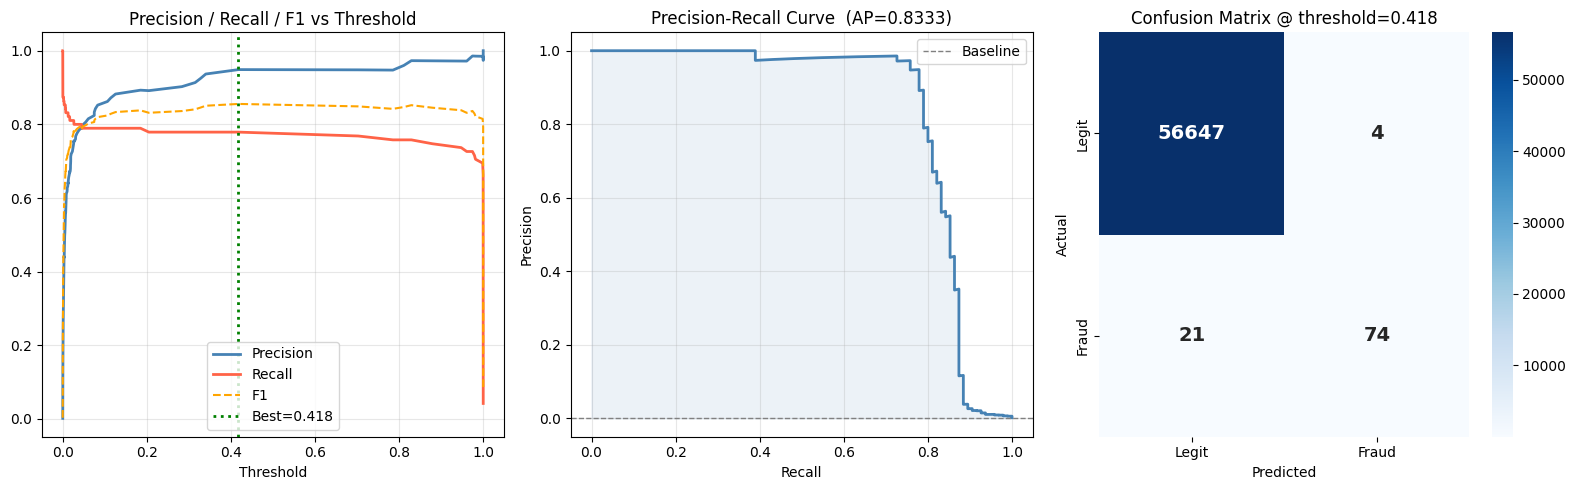

Threshold plots saved → threshold_plots.png


In [14]:
TARGET_RECALL_REFERENCE = 0.85
ref_mask = rec_arr_t >= TARGET_RECALL_REFERENCE
if ref_mask.any():
    ref_idx = np.argmax(prec_arr_t[ref_mask])  # best precision among those hitting the recall ref
    ref_thresh = thresh_arr[ref_mask][ref_idx]
    ref_prec = prec_arr_t[ref_mask][ref_idx]
    ref_rec = rec_arr_t[ref_mask][ref_idx]
    print(f"\n(For reference: forcing recall >= {TARGET_RECALL_REFERENCE} would require "
          f"threshold={ref_thresh:.4f}, giving precision={ref_prec:.4f}, recall={ref_rec:.4f} -"
          f" notice how much lower precision is versus the max-F1 choice above.)")

# %% Cell 19
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(thresh_arr, prec_arr[:-1], label="Precision", color="steelblue", lw=2)
ax.plot(thresh_arr, rec_arr[:-1],  label="Recall",    color="tomato",    lw=2)
f1_line = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
ax.plot(thresh_arr, f1_line, label="F1", color="orange", lw=1.5, linestyle="--")
ax.axvline(BEST_THRESHOLD, color="green", linestyle=":", lw=2, label=f"Best={BEST_THRESHOLD:.3f}")
ax.set_title("Precision / Recall / F1 vs Threshold")
ax.set_xlabel("Threshold")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(rec_arr, prec_arr, color="steelblue", lw=2)
ap = average_precision_score(y_test, y_prob)
ax.set_title(f"Precision-Recall Curve  (AP={ap:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.axhline(y_test.mean(), color="gray", linestyle="--", lw=1, label="Baseline")
ax.fill_between(rec_arr, prec_arr, alpha=0.1, color="steelblue")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[2]
cm = confusion_matrix(y_test, y_pred_tuned)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"],
            yticklabels=["Legit", "Fraud"], ax=ax,
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title(f"Confusion Matrix @ threshold={BEST_THRESHOLD:.3f}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("threshold_plots.png", dpi=130, bbox_inches="tight")
plt.show()
print("Threshold plots saved → threshold_plots.png")


In [15]:
tn, fp, fn, tp = cm.ravel()
print("\n-- Final Metrics Summary --------------------------------")
print(f"  ROC-AUC          : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Avg Precision    : {ap:.4f}")
print(f"  F1  (tuned)      : {f1_score(y_test, y_pred_tuned):.4f}  <- optimized for this")
print(f"  Recall (tuned)   : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"  Precision(tuned) : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  TP (caught fraud): {tp}")
print(f"  FN (missed fraud): {fn}  <- these are real losses")
print(f"  FP (false alarms): {fp}")

# %% Cell 21
print("\n" + "=" * 60)
print("STEP 10 — SAVE ARTIFACTS")
print("=" * 60)

with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

config = {
    "model_type":       clf_name,
    "best_threshold":   float(BEST_THRESHOLD),
    "train_mean":       float(train_mean),
    "train_p99":        float(train_p99),
    "scale_pos_weight": float(SPW),
    "numeric_features": numeric_features,
    "feature_order":    FEATURE_ORDER,    # exact column order model expects
    "optimization_target": "f1",
    "optuna_n_trials":  N_TRIALS,
    "best_params":      best.params,
}

with open("config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved artifacts:")
print("  model.pkl    — trained model")
print("  scaler.pkl   — RobustScaler (fitted on train only)")
print("  config.json  — threshold, feature order, train stats")
print(f"\nFeature order ({len(FEATURE_ORDER)} features):")
print(FEATURE_ORDER)
print("\nStreamlit app: load these 3 files and call:")
print("  X_new = engineer_features(raw_input)")
print("  X_new_scaled = scaler.transform(X_new[config['feature_order']])")
print("  prob = model.predict_proba(X_new_scaled)[0][1]")
print("  pred = 'FRAUD' if prob >= config['best_threshold'] else 'LEGIT'")



-- Final Metrics Summary --------------------------------
  ROC-AUC          : 0.9837
  Avg Precision    : 0.8333
  F1  (tuned)      : 0.8555  <- optimized for this
  Recall (tuned)   : 0.7789
  Precision(tuned) : 0.9487
  TP (caught fraud): 74
  FN (missed fraud): 21  <- these are real losses
  FP (false alarms): 4

STEP 10 — SAVE ARTIFACTS
Saved artifacts:
  model.pkl    — trained model
  scaler.pkl   — RobustScaler (fitted on train only)
  config.json  — threshold, feature order, train stats

Feature order (43 features):
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'is_night', 'log_amount', 'amount_log_sq', 'is_round_amount', 'is_small_amount', 'hour_of_day', 'hour_sin', 'hour_cos', 'v_sum_sq', 'v_max_abs', 'amount_to_mean', 'is_high_amount']

Streamlit app: load these 3 files and call:
  X_new = engineer_features(r

In [16]:
trials_df = study.trials_dataframe()
print("\n── Top 10 Trials ────────────────────────────────────────")
cols_show = ["number", "value", "user_attrs_recall", "user_attrs_precision", "params_classifier"]
cols_show = [c for c in cols_show if c in trials_df.columns]
print(trials_df.sort_values("value", ascending=False)[cols_show].head(10).to_string(index=False))

best = study.best_trial
print(f"\n── Best Trial ───────────────────────────────────────────")
print(f"  Classifier : {best.params.get('classifier')}")
print(f"  Recall     : {best.user_attrs.get('recall')}")
print(f"  Precision  : {best.user_attrs.get('precision')}")
print(f"  Params     : {best.params}")



── Top 10 Trials ────────────────────────────────────────
 number    value  user_attrs_recall  user_attrs_precision params_classifier
     15 0.870015             0.8333                0.9123               XGB
     26 0.867341             0.8307                0.9092               XGB
     23 0.864328             0.8254                0.9095               XGB
     12 0.862939             0.8254                0.9067               XGB
     27 0.862807             0.8254                0.9064               XGB
     29 0.862046             0.8201                0.9108               XGB
     19 0.861720             0.8333                0.8935               XGB
     24 0.860128             0.8280                0.8974               XGB
     17 0.859656             0.8201                0.9065               XGB
     14 0.858254             0.8254                0.8964               XGB

── Best Trial ───────────────────────────────────────────
  Classifier : XGB
  Recall     : 0.8333
  Pre

In [17]:
print("\n" + "=" * 60)
print("STEP 8 — RETRAIN BEST MODEL ON FULL TRAINING SET")
print("=" * 60)

p = best.params
clf_name = p.get("classifier")

if clf_name == "XGB":
    best_model = XGBClassifier(
        n_estimators     = p["xgb_n_estimators"],
        max_depth        = p["xgb_max_depth"],
        learning_rate    = p["xgb_lr"],
        subsample        = p["xgb_subsample"],
        colsample_bytree = p["xgb_colsample"],
        min_child_weight = p["xgb_min_child"],
        scale_pos_weight = p["xgb_spw"],
        eval_metric      = "aucpr",
        n_jobs           = -1,
        random_state     = 42,
        verbosity        = 0,
    )
elif clf_name == "LGBM":
    best_model = LGBMClassifier(
        n_estimators     = p["lgb_n_estimators"],
        num_leaves       = p["lgb_num_leaves"],
        max_depth        = p["lgb_max_depth"],
        learning_rate    = p["lgb_lr"],
        subsample        = p["lgb_subsample"],
        colsample_bytree = p["lgb_colsample"],
        min_child_samples= p["lgb_min_child"],
        reg_alpha        = p["lgb_alpha"],
        reg_lambda       = p["lgb_lambda"],
        scale_pos_weight = p["lgb_spw"],
        n_jobs           = -1,
        random_state     = 42,
        verbosity        = -1,
    )
else:
    best_model = RandomForestClassifier(
        n_estimators     = p["rf_n_estimators"],
        max_depth        = p["rf_max_depth"],
        min_samples_split= p["rf_min_split"],
        min_samples_leaf = p["rf_min_leaf"],
        class_weight     = "balanced",
        n_jobs           = -1,
        random_state     = 42,
    )

best_model.fit(X_train_proc.values, y_train)
y_prob = best_model.predict_proba(X_test_proc.values)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

print(f"\nModel: {clf_name}")
print("\n--- Default Threshold (0.5) ---")
print(classification_report(y_test, y_pred_default, target_names=["Legit", "Fraud"]))



STEP 8 — RETRAIN BEST MODEL ON FULL TRAINING SET

Model: XGB

--- Default Threshold (0.5) ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.95      0.77      0.85        95

    accuracy                           1.00     56746
   macro avg       0.97      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 — THRESHOLD TUNING  (now respects PRECISION_FLOOR, not just recall target)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 9 — THRESHOLD TUNING")
print("=" * 60)

TARGET_RECALL = 0.85
# PRECISION_FLOOR already defined in Step 7 (0.30) — reused here so the two
# stages of the pipeline actually agree on what "good enough" means.

prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_prob)
prec_arr_t = prec_arr[:-1]   # drop sklearn's synthetic last point (recall=0, no threshold)
rec_arr_t  = rec_arr[:-1]

# ── Show the real tradeoff first — no point picking blind ───────────────────
print("Precision/Recall at sampled thresholds (so the tradeoff is visible):")
sample_idx = np.linspace(0, len(thresh_arr) - 1, 15).astype(int)
print(f"{'threshold':>10} {'recall':>8} {'precision':>10}")
for i in sample_idx:
    print(f"{thresh_arr[i]:>10.4f} {rec_arr_t[i]:>8.4f} {prec_arr_t[i]:>10.4f}")

# ── Selection logic: BOTH constraints must hold, not just recall ────────────
# Priority 1: recall >= TARGET_RECALL AND precision >= PRECISION_FLOOR
both_mask = (rec_arr_t >= TARGET_RECALL) & (prec_arr_t >= PRECISION_FLOOR)

if both_mask.any():
    valid_thresholds = thresh_arr[both_mask]
    valid_precisions = prec_arr_t[both_mask]
    best_idx = np.argmax(valid_precisions)
    BEST_THRESHOLD = valid_thresholds[best_idx]
    print(f"\n✓ Found threshold satisfying BOTH recall≥{TARGET_RECALL} "
          f"AND precision≥{PRECISION_FLOOR}")

else:
    # No threshold hits both targets simultaneously — this model's PR curve
    # cannot deliver recall=0.85 without precision collapsing below the floor.
    # Falling back silently to a bad threshold (old behavior) hides this.
    # Instead: maximize F1 (best balance) and FLAG it loudly.
    f1_scores = 2 * prec_arr_t * rec_arr_t / (prec_arr_t + rec_arr_t + 1e-9)
    best_idx = np.argmax(f1_scores)
    BEST_THRESHOLD = thresh_arr[best_idx]

    print(f"\n⚠ WARNING: No threshold achieves recall≥{TARGET_RECALL} "
          f"AND precision≥{PRECISION_FLOOR} simultaneously.")
    print(f"  This RF model's PR curve cannot support both targets at once —")
    print(f"  pushing recall to {TARGET_RECALL} forces precision below the floor.")
    print(f"  Falling back to max-F1 threshold instead "
          f"(recall={rec_arr_t[best_idx]:.4f}, precision={prec_arr_t[best_idx]:.4f}).")
    print(f"  → Consider: lowering TARGET_RECALL, raising PRECISION_FLOOR's priority,")
    print(f"    or re-running Optuna with PRECISION_FLOOR enforced harder (Step 7).")

y_pred_tuned = (y_prob >= BEST_THRESHOLD).astype(int)

print(f"\nSelected threshold : {BEST_THRESHOLD:.4f}")
print(f"\n--- Tuned Threshold ({BEST_THRESHOLD:.4f}) ---")
print(classification_report(y_test, y_pred_tuned, target_names=["Legit", "Fraud"]))


STEP 9 — THRESHOLD TUNING
Precision/Recall at sampled thresholds (so the tradeoff is visible):
 threshold   recall  precision
    0.0000   1.0000     0.0017
    0.0000   1.0000     0.0018
    0.0000   1.0000     0.0020
    0.0000   1.0000     0.0021
    0.0000   1.0000     0.0023
    0.0000   1.0000     0.0026
    0.0000   1.0000     0.0029
    0.0000   1.0000     0.0034
    0.0000   1.0000     0.0039
    0.0000   1.0000     0.0047
    0.0000   0.9895     0.0058
    0.0000   0.9789     0.0077
    0.0000   0.9368     0.0110
    0.0000   0.9053     0.0213
    1.0000   0.0421     1.0000

✓ Found threshold satisfying BOTH recall≥0.85 AND precision≥0.3

Selected threshold : 0.0062

--- Tuned Threshold (0.0062) ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.55      0.85      0.67        95

    accuracy                           1.00     56746
   macro avg       0.78      0.93      0.83     56746
weighted

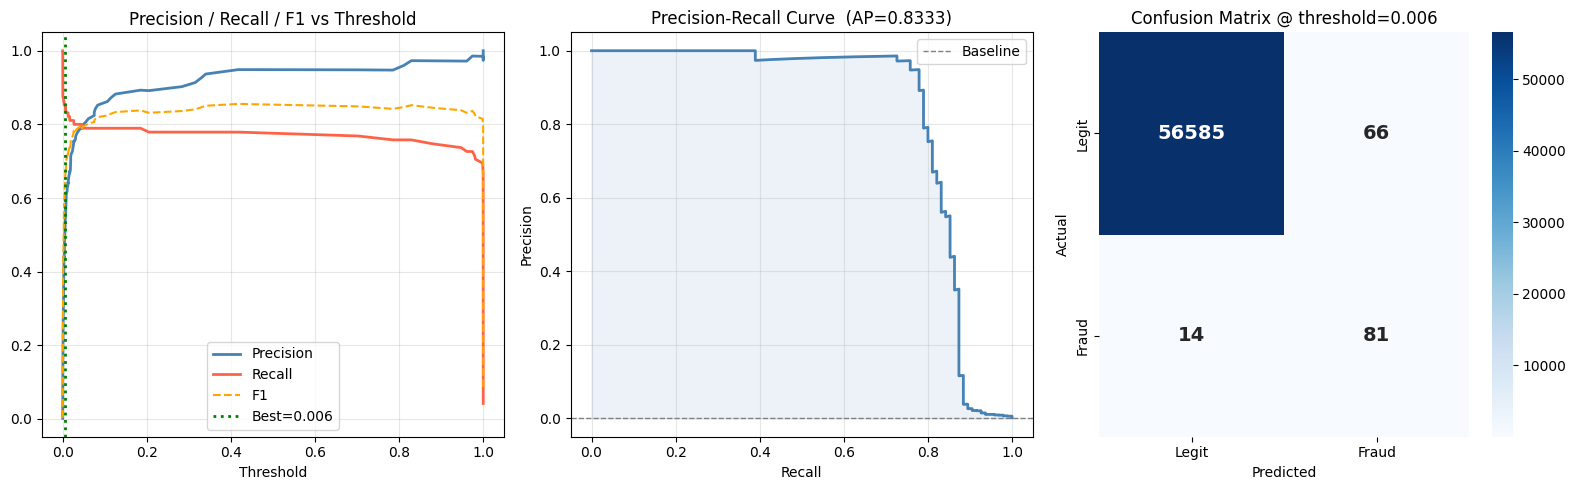

Threshold plots saved → threshold_plots.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(thresh_arr, prec_arr[:-1], label="Precision", color="steelblue", lw=2)
ax.plot(thresh_arr, rec_arr[:-1],  label="Recall",    color="tomato",    lw=2)
f1_line = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
ax.plot(thresh_arr, f1_line, label="F1", color="orange", lw=1.5, linestyle="--")
ax.axvline(BEST_THRESHOLD, color="green", linestyle=":", lw=2, label=f"Best={BEST_THRESHOLD:.3f}")
ax.set_title("Precision / Recall / F1 vs Threshold")
ax.set_xlabel("Threshold")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(rec_arr, prec_arr, color="steelblue", lw=2)
ap = average_precision_score(y_test, y_prob)
ax.set_title(f"Precision-Recall Curve  (AP={ap:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.axhline(y_test.mean(), color="gray", linestyle="--", lw=1, label="Baseline")
ax.fill_between(rec_arr, prec_arr, alpha=0.1, color="steelblue")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[2]
cm = confusion_matrix(y_test, y_pred_tuned)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"],
            yticklabels=["Legit", "Fraud"], ax=ax,
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title(f"Confusion Matrix @ threshold={BEST_THRESHOLD:.3f}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("threshold_plots.png", dpi=130, bbox_inches="tight")
plt.show()
print("Threshold plots saved → threshold_plots.png")


In [20]:
tn, fp, fn, tp = cm.ravel()
print("\n── Final Metrics Summary ────────────────────────────────")
print(f"  ROC-AUC          : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Avg Precision    : {ap:.4f}")
print(f"  F1  (tuned)      : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall (tuned)   : {recall_score(y_test, y_pred_tuned):.4f}  ← target ≥ 0.85")
print(f"  Precision(tuned) : {precision_score(y_test, y_pred_tuned):.4f}  ← target ≥ 0.30")
print(f"  TP (caught fraud): {tp}")
print(f"  FN (missed fraud): {fn}  ← these are real losses")
print(f"  FP (false alarms): {fp}")



── Final Metrics Summary ────────────────────────────────
  ROC-AUC          : 0.9837
  Avg Precision    : 0.8333
  F1  (tuned)      : 0.6694
  Recall (tuned)   : 0.8526  ← target ≥ 0.85
  Precision(tuned) : 0.5510  ← target ≥ 0.30
  TP (caught fraud): 81
  FN (missed fraud): 14  ← these are real losses
  FP (false alarms): 66


In [21]:
print("\n" + "=" * 60)
print("STEP 10 — SAVE ARTIFACTS")
print("=" * 60)

with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

config = {
    "model_type":       clf_name,
    "best_threshold":   float(BEST_THRESHOLD),
    "train_mean":       float(train_mean),
    "train_p99":        float(train_p99),
    "scale_pos_weight": float(SPW),
    "numeric_features": numeric_features,
    "feature_order":    FEATURE_ORDER,    # exact column order model expects
    "target_recall":    TARGET_RECALL,
    "optuna_n_trials":  N_TRIALS,
    "best_params":      best.params,
}

with open("config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved artifacts:")
print("  model.pkl    — trained model")
print("  scaler.pkl   — RobustScaler (fitted on train only)")
print("  config.json  — threshold, feature order, train stats")
print(f"\nFeature order ({len(FEATURE_ORDER)} features):")
print(FEATURE_ORDER)
print("\nStreamlit app: load these 3 files and call:")
print("  X_new = engineer_features(raw_input)")
print("  X_new_scaled = scaler.transform(X_new[config['feature_order']])")
print("  prob = model.predict_proba(X_new_scaled)[0][1]")
print("  pred = 'FRAUD' if prob >= config['best_threshold'] else 'LEGIT'")



STEP 10 — SAVE ARTIFACTS
Saved artifacts:
  model.pkl    — trained model
  scaler.pkl   — RobustScaler (fitted on train only)
  config.json  — threshold, feature order, train stats

Feature order (43 features):
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'is_night', 'log_amount', 'amount_log_sq', 'is_round_amount', 'is_small_amount', 'hour_of_day', 'hour_sin', 'hour_cos', 'v_sum_sq', 'v_max_abs', 'amount_to_mean', 'is_high_amount']

Streamlit app: load these 3 files and call:
  X_new = engineer_features(raw_input)
  X_new_scaled = scaler.transform(X_new[config['feature_order']])
  prob = model.predict_proba(X_new_scaled)[0][1]
  pred = 'FRAUD' if prob >= config['best_threshold'] else 'LEGIT'


--- Default Threshold (0.5) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.79      0.87        95

    accuracy                           1.00     56746
   macro avg       0.99      0.89      0.94     56746
weighted avg       1.00      1.00      1.00     56746



Saved to: c:\Users\ADMISTRASION\Desktop\Credit Card Fraud Analysis


['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'is_night', 'log_amount', 'is_round_amount', 'is_small_amount', 'amount_log_sq', 'hour_of_day', 'v_sum_sq', 'v_max_abs', 'amount_to_mean', 'is_high_amount']


['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'is_night', 'log_amount', 'is_round_amount', 'is_small_amount', 'amount_log_sq', 'hour_of_day', 'v_sum_sq', 'v_max_abs', 'amount_to_mean', 'is_high_amount']
